# FEMA Disaster Declarations EDA

Dataset: `data/fema/FEMA_Disaster_Declarations.csv`

This notebook performs exploratory data analysis for structure, completeness, date coverage, geographic coverage, and high-signal distributions. Run cells from top to bottom after installing the project dependencies.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent.parent


DATA_PATH = ROOT / "data" / "fema" / "FEMA_Disaster_Declarations.csv"
DATA_PATH

WindowsPath('C:/Users/kenny/Data Science Projects/quoll-intelligence/data/fema/FEMA_Disaster_Declarations.csv')

## Load And Inspect

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.drop(columns=[c for c in ["Unnamed: 0"] if c in df.columns])
date_cols = ["declarationDate", "incidentBeginDate", "incidentEndDate", "disasterCloseoutDate", "lastIAFilingDate", "lastRefresh"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

display(df.head())
display(df.shape)
display(df.dtypes.to_frame("dtype"))

,id,disasterNumber,state,femaDeclarationString,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared,incidentBeginDate,incidentEndDate,disasterCloseoutDate,tribalRequest,fipsStateCode,fipsCountyCode,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash
0,09e3f81a-5e16-4b72-b317-1c64e0cfa59c,5529,OR,FM-5529-OR,FM,2024-08-09,2024,Fire,LEE FALLS FIRE,False,False,True,True,2024-08-08,NaT,NaT,False,41,67,99067,Washington (County),24122,NaT,2024081001,10,R,2024-08-27 18:22:14.800000+00:00,ae87cf3c6ed795015b714af7166c7c295b2b67c7
1,59983f89-30bf-4888-b21b-62e8d57d9aac,5528,OR,FM-5528-OR,FM,2024-08-06,2024,Fire,ELK LANE FIRE,False,False,True,True,2024-08-04,NaT,NaT,False,41,31,99031,Jefferson (County),24116,NaT,2024080701,10,R,2024-08-27 18:22:14.800000+00:00,432cf0995c47e3895cea696ede5621b810460501
2,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0,5527,OR,FM-5527-OR,FM,2024-08-02,2024,Fire,MILE MARKER 132 FIRE,False,False,True,True,2024-08-02,NaT,NaT,False,41,17,99017,Deschutes (County),24111,NaT,2024080301,10,R,2024-08-27 18:22:14.800000+00:00,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa
3,98a7c5bb-2346-45aa-a1ca-0399440d4f0b,4312,CA,DR-4312-CA,DR,2017-05-02,2017,Severe Storm,FLOODING,False,False,True,True,2017-02-08,2017-02-11,2025-03-25,True,6,0,60347,Resighini Rancheria (Indian Reservation),17035,NaT,2017041001,9,NaN,2025-03-26 20:21:32.579000+00:00,432a3a64bdbb291ae26cf5a27a33deeabb380481
4,5229bbae-eee6-42b8-b277-edbafa8d6cb2,4251,AL,DR-4251-AL,DR,2016-01-21,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",False,False,True,True,2015-12-23,2015-12-31,2025-03-27,False,1,1,99001,Autauga (County),16003,NaT,2015122301,4,NaN,2025-03-27 12:21:46.559000+00:00,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3


(69546, 28)

,dtype
id,object
disasterNumber,int64
state,object
femaDeclarationString,object
declarationType,object
declarationDate,datetime64[ns]
fyDeclared,int64
incidentType,object
declarationTitle,object
ihProgramDeclared,bool


## Completeness And Keys

In [3]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    missing = frame.isna().sum()
    unique_values = []
    for col in frame.columns:
        try:
            unique_values.append(frame[col].nunique(dropna=True))
        except TypeError:
            unique_values.append(np.nan)
    return (
        pd.DataFrame({
            "missing_count": missing,
            "missing_pct": missing / len(frame) * 100,
            "dtype": frame.dtypes.astype(str),
            "unique_values": unique_values,
        })
        .sort_values("missing_pct", ascending=False)
    )


missing_summary(df).head(30)

,missing_count,missing_pct,dtype,unique_values
lastIAFilingDate,50120,72.067409,datetime64[ns],558
designatedIncidentTypes,47812,68.748742,object,116
disasterCloseoutDate,16551,23.798637,datetime64[ns],1990
incidentEndDate,1521,2.187042,datetime64[ns],3348
disasterNumber,0,0.000000,int64,5146
lastRefresh,0,0.000000,"datetime64[ns, UTC]",242
region,0,0.000000,int64,10
incidentId,0,0.000000,int64,4394
declarationRequestNumber,0,0.000000,int64,5146
designatedArea,0,0.000000,object,2959


In [4]:
key_cols = [c for c in ["id", "disasterNumber", "femaDeclarationString", "incidentId"] if c in df.columns]
pd.DataFrame({
    "column": key_cols,
    "unique_values": [df[c].nunique(dropna=True) for c in key_cols],
    "duplicate_rows_by_column": [df[c].duplicated().sum() for c in key_cols],
})

,column,unique_values,duplicate_rows_by_column
0,id,69546,0
1,disasterNumber,5146,64400
2,femaDeclarationString,5146,64400
3,incidentId,4394,65152


## Time Coverage

In [5]:
date_overview = []
for col in date_cols:
    if col in df.columns:
        date_overview.append({
            "column": col,
            "min": df[col].min(),
            "max": df[col].max(),
            "missing_pct": df[col].isna().mean() * 100,
        })
pd.DataFrame(date_overview)

,column,min,max,missing_pct
0,declarationDate,1953-05-02 00:00:00,2026-01-24 00:00:00,0.000000
1,incidentBeginDate,1953-05-02 00:00:00,2026-01-23 00:00:00,0.000000
2,incidentEndDate,1953-05-02 00:00:00,2025-12-30 00:00:00,2.187042
3,disasterCloseoutDate,1954-06-01 00:00:00,2026-01-27 00:00:00,23.798637
4,lastIAFilingDate,1998-10-24 00:00:00,2026-02-20 00:00:00,72.067409
5,lastRefresh,2024-08-27 18:22:14.800000+00:00,2026-01-30 14:01:19.257000+00:00,0.000000


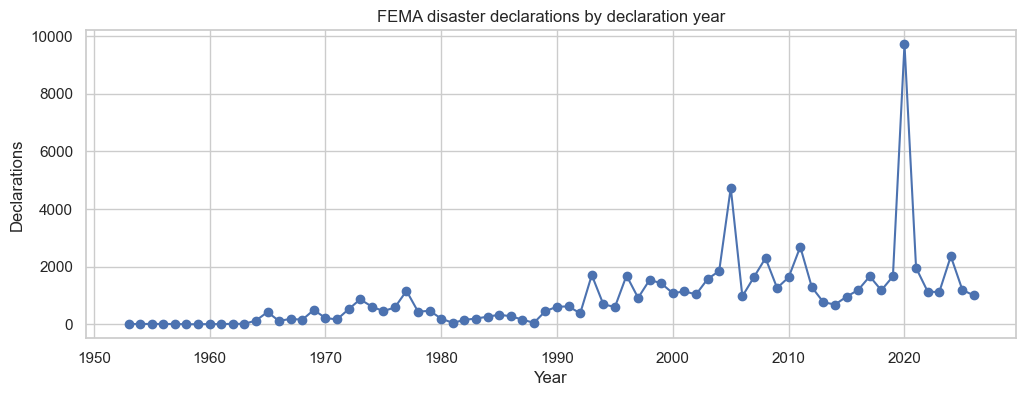

In [6]:
annual = df.assign(year=df["declarationDate"].dt.year).groupby("year", dropna=False).size()
ax = annual.plot(kind="line", marker="o", figsize=(12, 4), title="FEMA disaster declarations by declaration year")
ax.set_xlabel("Year")
ax.set_ylabel("Declarations")
plt.show()

## Geography And Incident Types

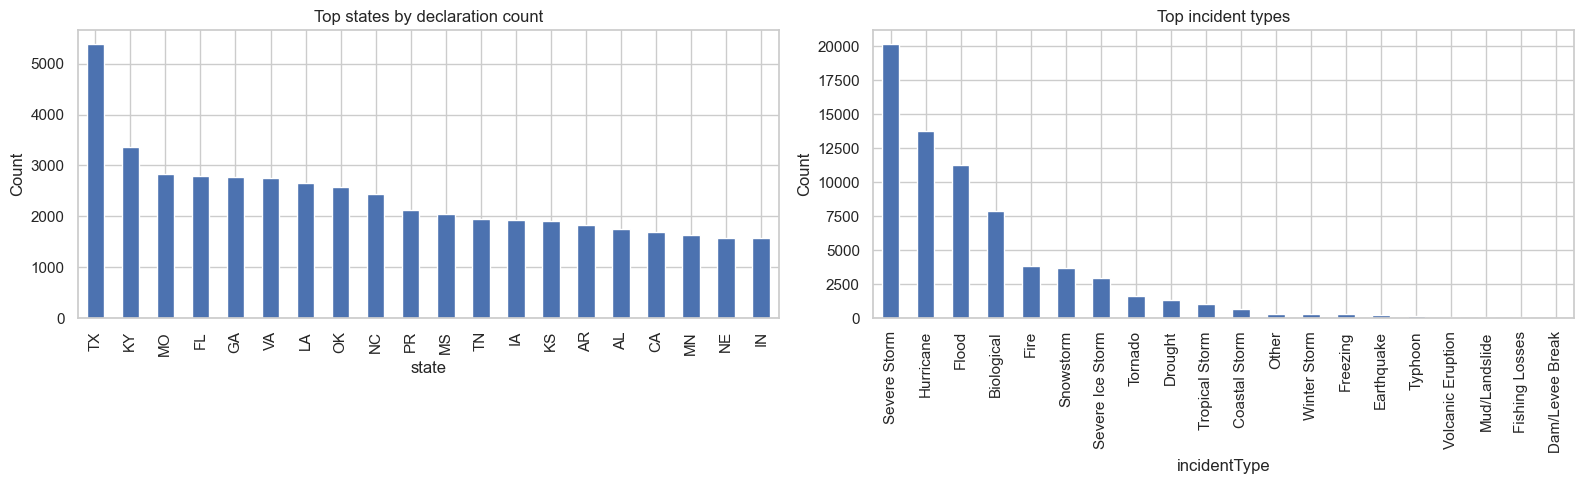

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df["state"].value_counts().head(20).plot(kind="bar", ax=axes[0], title="Top states by declaration count")
df["incidentType"].value_counts().head(20).plot(kind="bar", ax=axes[1], title="Top incident types")
for ax in axes:
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
pd.crosstab(df["state"], df["incidentType"]).assign(total=lambda x: x.sum(axis=1)).sort_values("total", ascending=False).head(20)

incidentType,Biological,Chemical,Coastal Storm,Dam/Levee Break,Drought,Earthquake,Fire,Fishing Losses,Flood,Freezing,Human Cause,Hurricane,Mud/Landslide,Other,Severe Ice Storm,Severe Storm,Snowstorm,Straight-Line Winds,Terrorist,Tornado,Toxic Substances,Tropical Depression,Tropical Storm,Tsunami,Typhoon,Volcanic Eruption,Winter Storm,total
state,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TX,515,0,42,0,149,0,1238,0,613,16,0,1370,0,56,554,760,0,0,0,50,0,0,0,0,0,0,23,5386
KY,240,0,0,0,0,0,41,0,494,0,0,120,0,1,248,1715,332,0,0,129,1,0,34,0,0,0,0,3355
MO,230,0,0,0,94,0,1,0,522,0,0,115,0,0,373,1465,0,0,0,30,0,0,0,0,0,0,0,2830
FL,150,0,25,0,0,0,277,0,74,147,4,1432,0,2,0,376,0,0,0,38,0,0,266,0,0,0,0,2791
GA,320,0,0,0,144,0,17,0,62,6,0,1031,0,0,152,534,93,0,0,157,0,0,249,0,0,0,0,2765
VA,276,0,0,0,100,10,11,0,281,39,0,877,0,0,33,605,462,0,1,0,0,0,61,0,0,0,0,2756
LA,144,0,204,0,0,0,16,0,363,0,0,1450,0,46,136,163,42,0,0,24,1,0,0,0,0,0,64,2653
OK,239,0,0,0,0,0,248,0,225,0,2,77,0,0,596,1049,4,0,0,142,0,0,0,0,0,0,0,2582
NC,207,0,0,0,49,0,15,0,63,0,0,1304,1,0,84,245,193,0,0,42,0,7,221,0,0,0,0,2431


## Program Flags

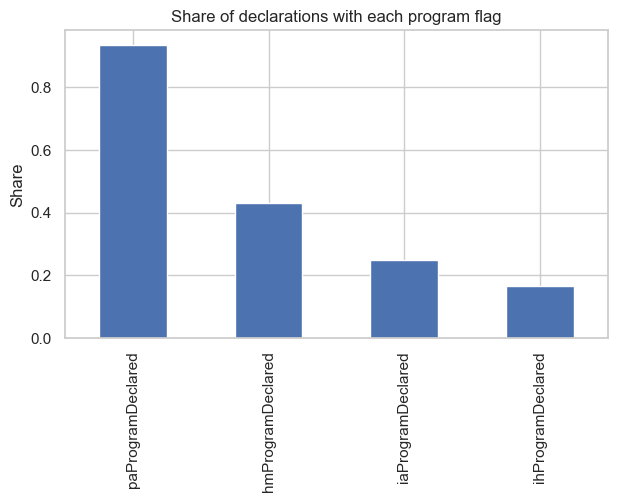

,share
paProgramDeclared,0.935539
hmProgramDeclared,0.431671
iaProgramDeclared,0.247131
ihProgramDeclared,0.167213


In [9]:
program_cols = [c for c in ["ihProgramDeclared", "iaProgramDeclared", "paProgramDeclared", "hmProgramDeclared"] if c in df.columns]
program_rates = df[program_cols].apply(pd.to_numeric, errors="coerce").mean().sort_values(ascending=False)
ax = program_rates.plot(kind="bar", figsize=(7, 4), title="Share of declarations with each program flag")
ax.set_ylabel("Share")
plt.show()
program_rates.to_frame("share")